In [1]:
import os
os.chdir('../../../../..')

In [2]:
import numpy as np

from sklearn.cluster import AgglomerativeClustering, SpectralClustering, DBSCAN, KMeans
from kmedoids import KMedoids
from hdbscan import HDBSCAN

from src.datasets import QM9Dataset
from src.helper_functions import plot_molecules_with_py3dmol, create_chemiscope_viewer, plot_distance_matrix_projection,benchmark_functional_groups, evaluate_distance_matrix_clustering_sweep, average_numeric_by_cluster,evaluate_hdbscan_grid

In [3]:
qm9 = QM9Dataset(limit=5000, sampling_strategy="stratified", stratify_by=["num_atoms", "gap"], descriptors=["morgan"])
df = qm9.load()
molecules = qm9.get_molecules()

2026-05-05 08:53:26.343 | INFO     | src.datasets:load:867 - Loading cached full QM9 dataset from: data/QM9/dataset_cleaned.parquet
2026-05-05 08:53:26.757 | INFO     | src.datasets:_sample_qm9_df:1073 - QM9 sampling complete: strategy=stratified, requested_limit=5000, returned_rows=5000.
2026-05-05 08:53:26.758 | INFO     | src.datasets:_add_requested_descriptors:202 - Applying requested QM9 descriptors to sampled dataframe (rows=5000).
2026-05-05 08:53:26.759 | INFO     | src.features:compute_morgan_fingerprints:225 - Computing Morgan Fingerprints (Radius=3, Size=2048)...
2026-05-05 08:53:35.897 | INFO     | src.datasets:_add_requested_descriptors:227 - Added descriptor column(s): ['morgan_fingerprint']
2026-05-05 08:53:36.679 | SUCCESS  | src.datasets:get_molecules:1689 - Saved 5000 molecules to data/QM9/qm9_subset.xyz (failed: 0, requested: 5000).


In [4]:
plot_molecules_with_py3dmol(molecules[0:3])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

In [5]:
X = np.array(df['morgan_fingerprint'].to_list())

In [4]:
dist_matrix = qm9.get_distance_matrix(descriptor="morgan", dist_type="jaccard", force_calculate=True)

2026-05-05 08:53:40.267 | INFO     | src.datasets:get_distance_matrix:1500 - Calculating distance matrix for morgan using jaccard distance.
2026-05-05 08:54:00.055 | SUCCESS  | src.distance:_compute_and_save:74 - Saved distance matrix to data/QM9/dist_morgan_jaccard.npy


In [7]:
n = 10
triu_indices = np.triu_indices_from(dist_matrix, k=1)
distances = dist_matrix[triu_indices]
molecule_pairs = list(zip(triu_indices[0], triu_indices[1]))
smallest_indices = np.argsort(distances)[:n]
closest_pairs = [molecule_pairs[i] for i in smallest_indices]
print("Closest molecule pairs (indices):", closest_pairs)
mols = [(molecules[idx1], molecules[idx2]) for idx1, idx2 in closest_pairs]

Closest molecule pairs (indices): [(np.int64(1877), np.int64(1879)), (np.int64(3065), np.int64(3088)), (np.int64(507), np.int64(2811)), (np.int64(7), np.int64(3228)), (np.int64(4243), np.int64(4271)), (np.int64(539), np.int64(2647)), (np.int64(391), np.int64(4614)), (np.int64(3530), np.int64(3539)), (np.int64(566), np.int64(4599)), (np.int64(629), np.int64(4620))]


In [8]:
plot_molecules_with_py3dmol(mols[2])

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

# Determining the best number of clusters for each clustering method

Evaluating epsilon and min samples: 100%|██████████| 10/10 [00:09<00:00,  1.00it/s]


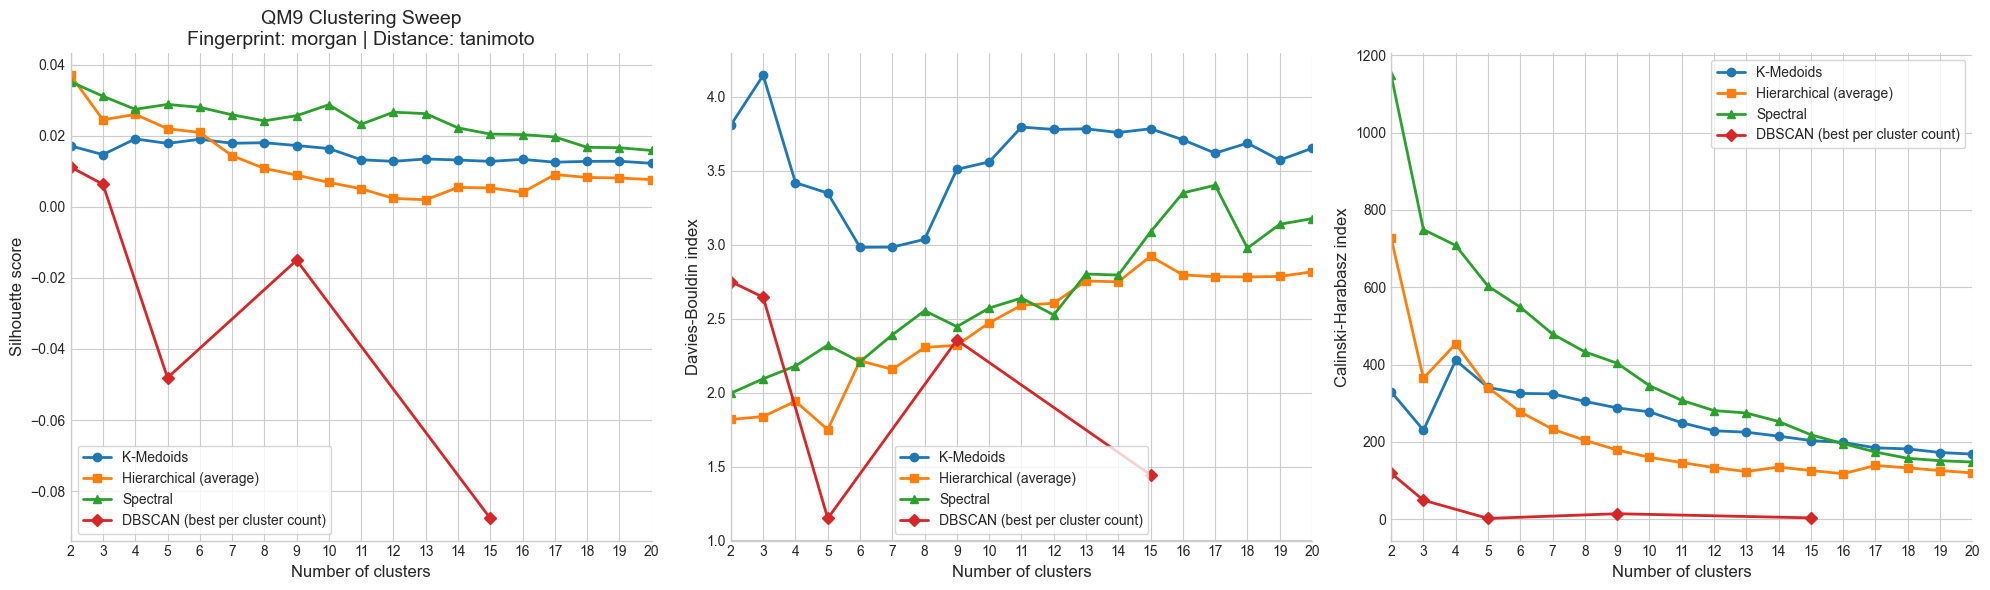

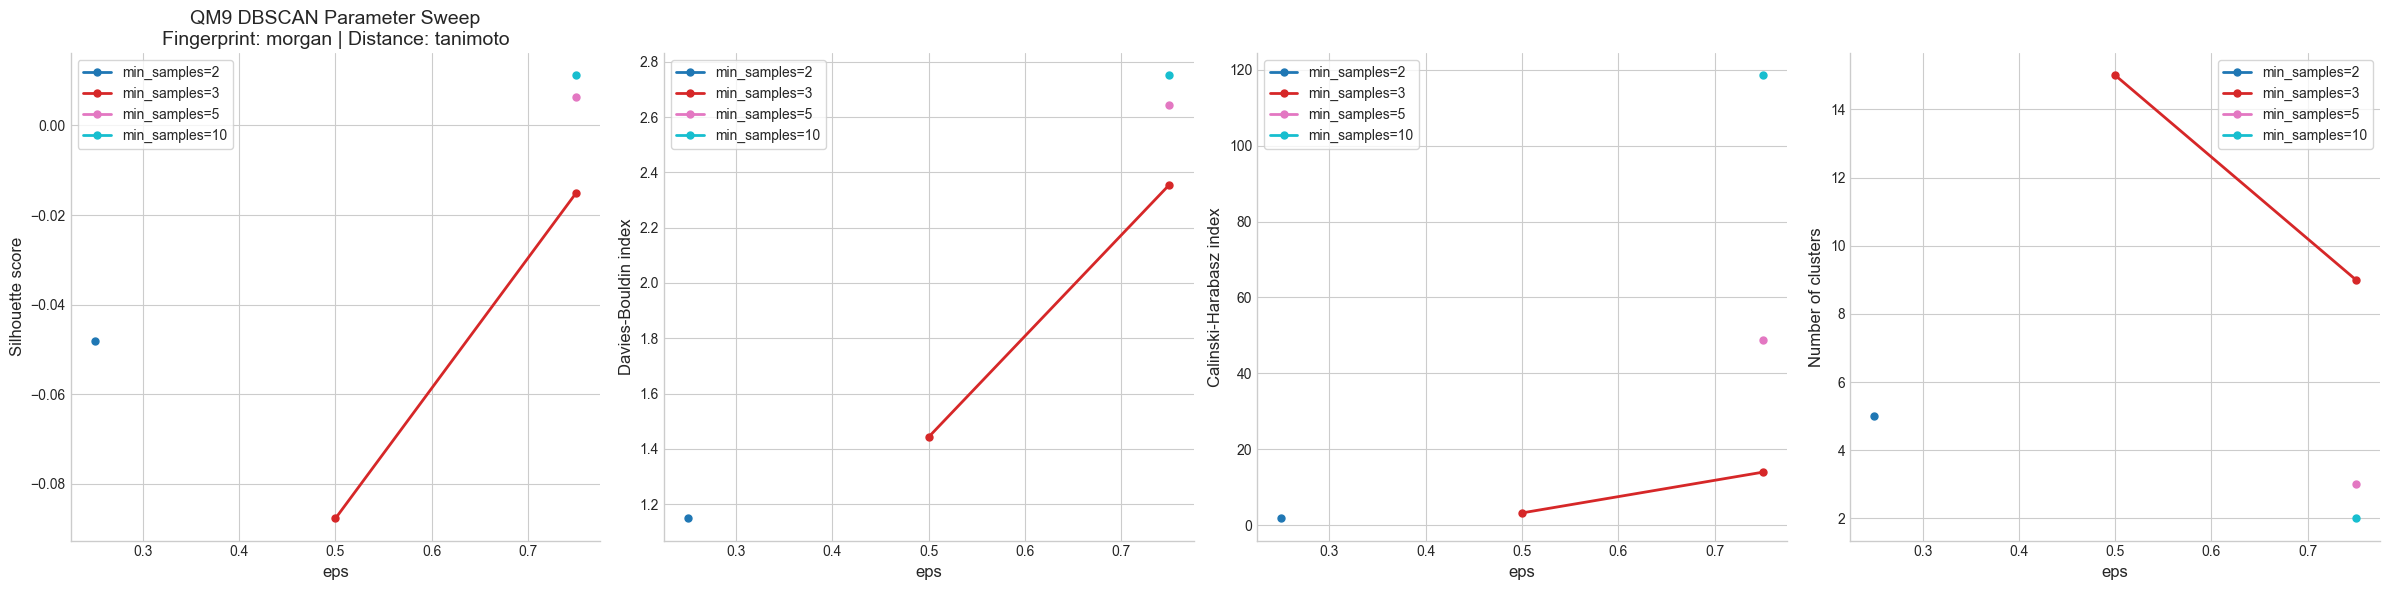

2026-04-27 19:19:13.739 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:985 - Saved clustering sweep plot to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.png
2026-04-27 19:19:13.740 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:987 - Saved DBSCAN evaluation plot to figures/qm9/clustering/tanimoto/morgan/dbscan_parameter_sweep.png
2026-04-27 19:19:13.740 | SUCCESS  | src.helper_functions:evaluate_distance_matrix_clustering_sweep:988 - Saved clustering sweep results to figures/qm9/clustering/tanimoto/morgan/clustering_sweep_2_to_20_clusters.json


In [9]:
out = evaluate_distance_matrix_clustering_sweep(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    dataset_name="qm9",
)

# Hiercical Clustering on Distance Matrix

In [5]:
model_hier = AgglomerativeClustering(metric='precomputed', n_clusters=3, linkage='average')
labels_hier = model_hier.fit_predict(dist_matrix)
df = df.with_columns(labels_hier=labels_hier)
print(np.unique(labels_hier, return_counts=True))

(array([0, 1, 2]), array([4201,    5,  794]))


In [11]:
create_chemiscope_viewer(df, dist_matrix, labels_hier, 't-SNE')

2026-04-27 19:19:14.127 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running t-SNE dimensionality reduction...
2026-04-27 19:19:14.127 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:19:52.883 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:19:52.891 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:19:54.110 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_t-SNE_clustering.json
2026-04-27 19:19:54.194 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_t-SNE_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - t-SNE Clustering'}, settings={'map': {'x': {'property': 't-SNE_1'}, 'y'…

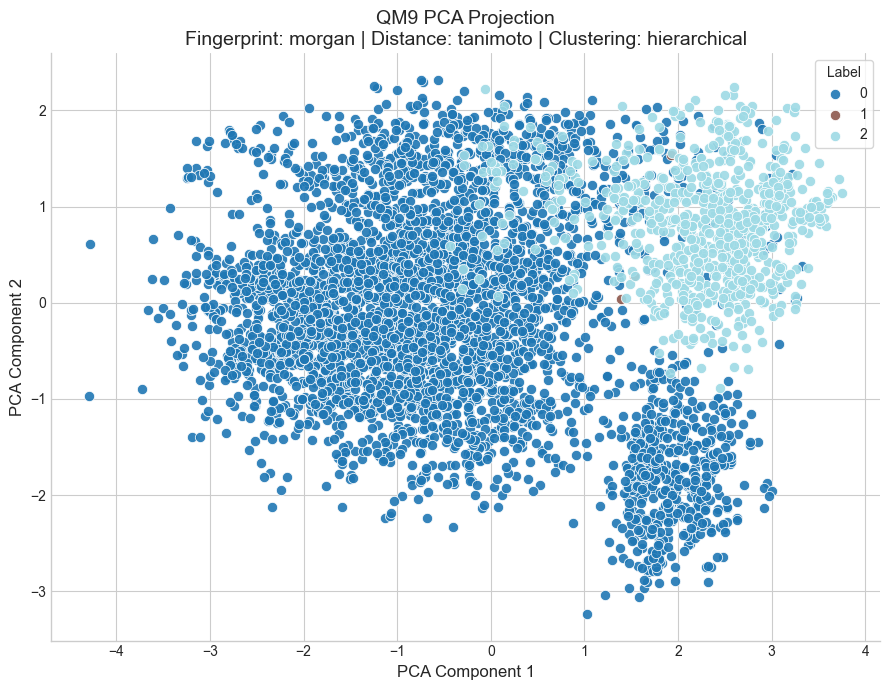

2026-05-05 08:54:09.807 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:604 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_hierarchical_projection.png


{'coords': array([[ 1.73608812, -1.93505213],
        [ 1.4120263 , -1.1809183 ],
        [ 1.08101742,  2.10470239],
        ...,
        [ 2.11681917, -0.91255404],
        [ 1.70180246, -1.40664182],
        [ 2.77070226, -1.44613484]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_hierarchical_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'hierarchical'}

In [6]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hier,
    clustering_method="hierarchical"
)

In [13]:
average_numeric_by_cluster(df, "labels_hier")

shape: (3, 71)
┌─────────────┬───────┬─────────────────┬─────────────┬────────────┬─────────┬──────────┬─────────────────┬─────────────────┬─────────────────┬───────────┬─────────────────┬──────────────┬─────────────────┬───────────┬──────────────┬─────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─────────────────┬─────────────────┬────────────────┬─────────────────┬─────────────────┬─────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬──

labels_hier,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,4103,2.090944,0.0,122.887399,0.046308,33.691445,0.897382,12.827679,8.778699,1.74214,0.012917,0.010968,2.232025,18.883987,2.06757,2.3495,0.073601,0.133917,0.792481,0.884718,1.834024,6.565684,0.487936,0.817451,5.241287,6.341457,39.734828,1.263278,0.000244,0.396295,0.002194,0.104314,0.132342,0.001706,0.042895,0.143066,0.595418,0.0,2.600783,75.707887,-6.634671,0.440882,7.075507,1199.626652,4.212364,-11094.834035,-11094.59954,-11094.573834,-11095.747027,32.18084,-77.766469,-78.246393,-78.697134,-72.349475,154.417582,1.391685,1.134321,86.253961,1.291738,12.454302,39.734828,1220,"""Acyclic""",12.454302,320,"""Acyclic""",12.454302,1,null,0.0
1,895,1.853327,0.0,121.927374,0.189944,49.739665,0.682283,12.966516,8.784358,1.263687,0.927374,0.09162,3.461453,15.639106,2.033032,1.994413,0.038952,0.660347,0.300701,1.064804,2.864804,6.135196,0.225698,3.427933,1.669274,6.417877,29.281564,1.25896,0.015642,0.111732,0.147486,0.282682,0.02905,0.001117,0.011173,0.025698,0.213408,0.006704,3.021473,72.665765,-6.096536,-0.36881,5.727741,1148.107295,3.304337,-11530.988587,-11530.772909,-11530.747214,-11531.883898,29.11882,-68.00634,-68.390078,-68.76409,-63.41944,3.945354,1.419099,1.036754,11.396648,88.603352,0.0,29.281564,335,"""c1cc[nH]c1""",7.709497,37,"""C1CCCC1""",45.363128,1,null,0.0
2,2,1.719457,0.0,121.5,-2.0,101.5,0.419839,13.281996,8.5,0.5,0.0,0.0,5.0,15.0,1.923077,2.5,0.166667,0.583333,0.25,3.0,3.0,5.0,0.5,2.0,1.0,6.0,26.0,1.23226,0.0,0.0,0.0,2.0,0.0,0.0,0.0,0.0,0.5,0.0,7.2463,70.764999,-5.157918,-1.372814,3.783743,1053.075623,2.808678,-11999.570801,-11999.339844,-11999.313965,-12000.470215,30.969001,-57.702225,-58.01053,-58.34462,-53.578815,2.32006,1.857145,1.062295,50.0,0.0,50.0,26.0,2,"""C1CO1""",50.0,2,"""C1CC1""",50.0,1,null,0.0


In [14]:
benchmark_functional_groups(df, "labels_hier")

[{'Cluster': 0,
  'Size': 4103,
  'Top_FG_1': 'fr_ether (49.6%)',
  'Top_FG_2': 'fr_alcohol (33.3%)',
  'Top_FG_3': 'fr_ketone (13.6%)'},
 {'Cluster': 1,
  'Size': 895,
  'Top_FG_1': 'fr_amine (25.6%)',
  'Top_FG_2': 'fr_ether (20.2%)',
  'Top_FG_3': 'fr_phenol (13.3%)'},
 {'Cluster': 2,
  'Size': 2,
  'Top_FG_1': 'fr_amine (100.0%)',
  'Top_FG_2': 'fr_ether (50.0%)',
  'Top_FG_3': 'fr_benzene (0.0%)'}]

# KMedoids

In [15]:
model_km = KMedoids(n_clusters=20, metric="precomputed")
labels_km = model_km.fit_predict(dist_matrix)
df = df.with_columns(labels_km=labels_km)

In [16]:
create_chemiscope_viewer(df, dist_matrix, labels_km, 'PCA')

2026-04-27 19:19:55.715 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:19:55.716 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:20:21.817 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:20:21.822 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:20:22.183 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:20:22.259 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

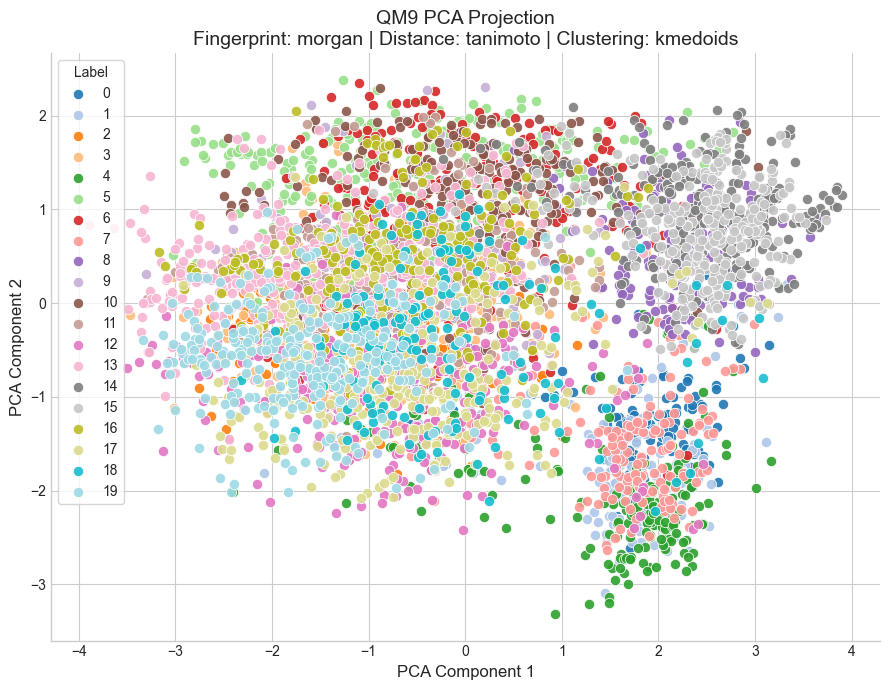

2026-04-27 19:20:23.178 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_kmedoids_projection.png


{'coords': array([[ 1.74521539, -1.95716742],
        [ 1.41417129, -1.11405265],
        [ 1.17573865,  1.94036107],
        ...,
        [-1.71206389, -0.68572605],
        [ 2.50105069, -1.7803237 ],
        [ 2.69705941, -1.49821204]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_kmedoids_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'kmedoids'}

In [17]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_km,
    clustering_method="kmedoids"
)

In [18]:
average_numeric_by_cluster(df, "labels_km")

shape: (20, 72)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬────────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬───────────┬────────┬────────┬─────────────┬────────────────┬──────────────┬─────────────┬────────────────┬────────────────┬──────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬─

labels_km,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
u64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,175,2.020818,0.0,125.16,-0.125714,50.028571,0.863698,12.996425,8.657143,0.211429,0.034286,0.034286,3.194286,19.097143,1.914978,4.622857,0.027048,0.290361,0.682592,1.08,2.371429,6.057143,0.177143,1.417143,3.868571,7.285714,38.857143,1.235587,0.0,0.342857,0.011429,0.354286,0.565714,0.022857,0.085714,0.097143,0.617143,0.0,3.082234,73.719543,-6.748968,-0.089953,6.658953,1544.984278,4.282437,-11819.446035,-11819.172581,-11819.146897,-11820.431674,34.797251,-76.959113,-77.412413,-77.871391,-71.52363,4.338596,0.992976,0.819839,0.034286,17.714286,3.428571,78.857143,38.857143,15,"""Acyclic""",78.857143,4,"""Acyclic""",78.857143,1,null,0.0
1,154,1.91327,0.0,120.571429,0.051948,35.11039,0.921795,12.789075,8.649351,0.344156,0.090909,0.038961,2.246753,17.688312,1.923451,3.5,0.274735,0.19479,0.530476,0.850649,1.831169,5.045455,1.798701,1.142857,3.461039,7.071429,34.383117,1.242227,0.0,0.409091,0.025974,0.103896,0.266234,0.0,0.071429,0.363636,0.233766,0.0,2.5667,76.145325,-6.803553,-0.354419,6.449116,1360.905654,3.850617,-11024.88214,-11024.616782,-11024.591068,-11025.844498,34.52961,-74.493051,-74.904134,-75.329549,-69.424768,4028.601279,1.158735,0.940271,0.090909,23.376623,9.090909,67.532468,34.383117,25,"""Acyclic""",67.532468,9,"""Acyclic""",67.532468,1,null,0.0
2,212,2.18656,0.0,124.113208,0.533019,18.792453,0.911566,12.831278,8.849057,2.080189,0.014151,0.014151,1.584906,21.400943,2.090991,2.985849,0.010613,0.064138,0.925249,0.54717,1.245283,7.580189,0.080189,0.45283,6.731132,6.518868,46.891509,1.259736,0.0,0.141509,0.0,0.09434,0.014151,0.0,0.028302,0.009434,0.825472,0.0,1.470367,81.50934,-6.461883,1.455899,7.917846,1228.197723,4.964495,-10697.275522,-10697.029626,-10697.003932,-10698.193281,34.274307,-85.739389,-86.301466,-86.814571,-79.624435,3.072146,1.360252,1.144292,0.023585,98.584906,1.415094,0.0,46.891509,118,"""C1CC1""",16.037736,53,"""C1CC1""",18.396226,1,null,0.0
3,272,2.106953,0.0,123.176471,-0.279412,39.158088,0.922719,12.819884,8.775735,1.941176,0.0,0.0,2.547794,17.849265,2.093459,2.077206,0.019695,0.20929,0.771014,1.025735,2.058824,6.713235,0.136029,1.275735,4.816176,5.915441,37.713235,1.270105,0.0,0.5,0.0,0.095588,0.253676,0.007353,0.014706,0.066176,0.338235,0.0,3.036386,72.883677,-6.617639,-0.384461,6.233208,1127.129549,3.884499,-11422.011828,-11421.785894,-11421.760182,-11422.916906,30.935,-74.213938,-74.663145,-75.087694,-69.081257,3.300876,1.409861,1.153024,0.014706,100.0,0.0,0.0,37.713235,131,"""C1CC1""",11.397059,54,"""C1CC1""",16.544118,1,null,0.0
4,186,1.991585,0.0,121.564516,0.274194,44.607527,0.824216,12.90731,8.634409,0.354839,0.069892,0.048387,2.44086,19.086022,1.928439,4.344086,0.199599,0.083122,0.717279,1.107527,2.166667,5.354839,1.22043,0.462366,4.510753,6.919355,38.467742,1.238776,0.0,0.72043,0.010753,0.166667,0.021505,0.0,0.005376,0.05914,0.295699,0.0,3.130047,76.651774,-7.125009,0

# Spectral

In [ ]:
kernel = np.exp(-dist_matrix**2 / (2 * np.std(dist_matrix)**2))
model_spectral = SpectralClustering(
                n_clusters=3,
                affinity="precomputed",
                assign_labels='kmeans',
                random_state=42,
            )
# 
labels_spectral = model_spectral.fit_predict(kernel)
df = df.with_columns(labels_spectral=labels_spectral)
print(np.unique(labels_spectral, return_counts=True))

In [20]:
# create_chemiscope_viewer(df, dist_matrix, labels_spectral, 'PCA')

In [21]:
labels_km

array([ 4,  0, 10, ..., 19,  7,  4], shape=(5000,), dtype=uint64)

In [ ]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_spectral,
    clustering_method="spectral"
)

In [23]:
# average_numeric_by_cluster(df, "labels_spectral")

# DBSCAN 

In [24]:
model_db = DBSCAN(
    eps=0.8,
    min_samples=2,
    metric='precomputed',
)

labels_db = model_db.fit_predict(dist_matrix)
df = df.with_columns(labels_db=labels_db)
print(np.unique(labels_db, return_counts=True))

(array([-1,  0,  1,  2,  3,  4]), array([  26, 4965,    2,    3,    2,    2]))


In [25]:
create_chemiscope_viewer(df, dist_matrix, labels_db, 'PCA')

2026-04-27 19:20:24.321 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:20:24.321 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:20:50.359 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:20:50.366 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:20:50.728 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:20:50.800 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

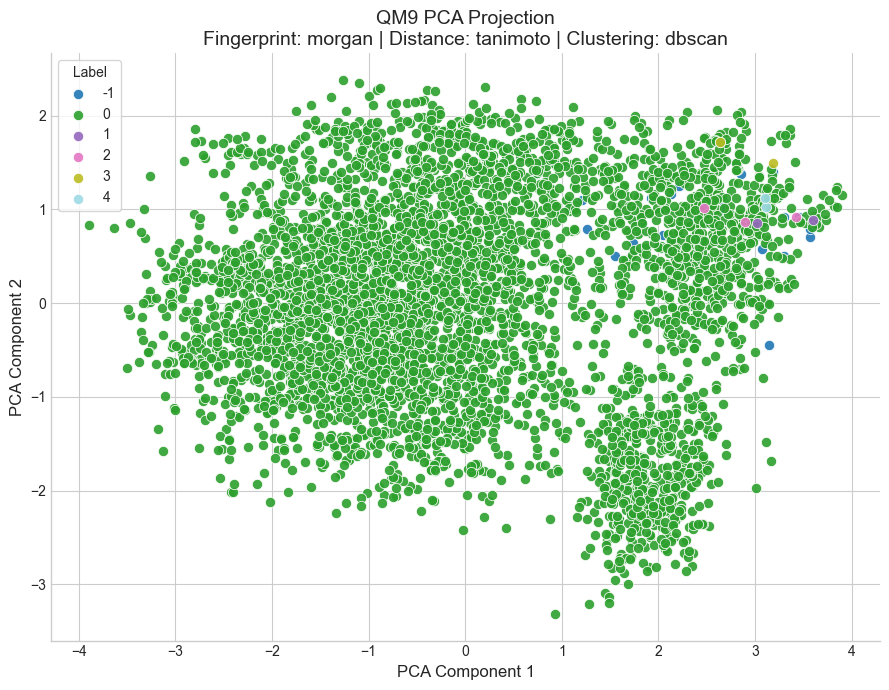

2026-04-27 19:20:52.925 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png


{'coords': array([[ 1.74521539, -1.95716742],
        [ 1.41417129, -1.11405265],
        [ 1.17573865,  1.94036107],
        ...,
        [-1.71206389, -0.68572605],
        [ 2.50105069, -1.7803237 ],
        [ 2.69705941, -1.49821204]], shape=(5000, 2)),
 'figure_path': PosixPath('figures/qm9/clustering/tanimoto/morgan/pca_dbscan_projection.png'),
 'output_dir': PosixPath('figures/qm9/clustering/tanimoto/morgan'),
 'clustering_method': 'dbscan'}

In [26]:
plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_db,
    clustering_method="dbscan"
)

In [27]:
clusters = average_numeric_by_cluster(df, "labels_db")
clusters.show(limit=25)

shape: (6, 73)
┌───────────┬───────┬────────────────┬─────────────┬────────────┬─────────┬─────────┬────────────────┬────────────────┬────────────────┬───────────┬────────────────┬──────────────┬────────────────┬───────────┬──────────────┬────────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬────────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬─

labels_db,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,26,1.867795,0.0,121.269231,0.038462,53.461538,0.530537,13.014666,8.807692,1.615385,0.615385,0.0,3.769231,15.076923,2.079277,0.961538,0.0,0.767491,0.232509,0.923077,2.846154,6.346154,0.0,3.730769,1.307692,6.115385,28.461538,1.268127,0.0,0.038462,0.0,0.346154,0.038462,0.038462,0.0,0.038462,0.230769,0.0,3.538765,72.274616,-6.058092,-0.935444,5.122543,1002.053277,3.036979,-11423.852802,-11423.661621,-11423.636005,-11424.714806,26.603462,-64.414504,-64.786646,-65.136546,-60.058236,3.760153,1.64421,1.173734,0.807692,12.307692,42.307692,53.846154,3.846154,28.461538,26,"""C1=Cn2nncc2OC1""",3.846154,10,"""C1CC2CCCC2C1""",23.076923,1,null,0.0
0,4965,2.049839,0.0,122.723263,0.071903,36.447331,0.861388,12.851303,8.779255,1.656596,0.173414,0.025579,2.442296,18.326485,2.061227,2.296274,0.067912,0.224156,0.707932,0.916818,2.012689,6.489627,0.444109,1.267271,4.625579,6.356898,37.933132,1.262455,0.003021,0.347231,0.028399,0.136153,0.114199,0.00141,0.037462,0.122659,0.529507,0.001208,2.672894,75.183853,-6.539414,0.306046,6.845426,1191.764673,4.057416,-11170.885307,-11170.653882,-11170.628177,-11171.795479,31.670487,-76.104995,-76.568374,-77.006028,-70.829823,128.294323,1.39481,1.116374,0.175025,10.246928,73.031219,16.676737,10.292044,37.933132,1495,"""Acyclic""",10.292044,321,"""C1CCCC1""",13.353474,1,null,0.0
1,2,1.733333,0.0,117.0,-0.5,60.0,0.077586,13.345299,8.5,2.0,2.0,0.0,5.0,13.5,2.15,0.5,0.0,0.875,0.125,1.0,3.0,6.5,0.0,3.0,0.5,6.0,23.5,1.258649,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.35045,62.264999,-6.698082,-0.223133,6.473589,812.463898,2.473474,-11140.875,-11140.711914,-11140.686035,-11141.696289,22.5555,-55.388834,-55.707632,-56.003147,-51.620045,4.565855,2.12706,1.452895,1.0,11.0,0.0,100.0,0.0,23.5,2,"""c1nc2[nH+]ncn2[nH]1""",50.0,1,"""C1CC2CCCC2C1""",100.0,1,null,0.0
2,3,1.72381,0.0,123.0,0.333333,74.333333,0.339601,13.113547,9.0,1.0,0.0,0.0,4.333333,14.666667,2.0,1.0,0.0,1.0,0.0,1.333333,2.666667,5.666667,0.0,4.666667,0.0,6.0,25.333333,1.261597,0.0,0.333333,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,4.087467,77.883334,-6.579713,-2.13428,4.444526,1034.001424,2.934004,-11564.441732,-11564.243815,-11564.218099,-11565.32194,27.424,-63.730106,-64.084743,-64.427389,-59.44493,2.59871,1.759727,1.102507,1.0,15.0,100.0,0.0,0.0,25.333333,3,"""C1=CN=CNC=C1""",33.333333,1,"""C1CCCCCC1""",100.0,1,null,0.0
3,2,1.664835,0.0,125.5,0.0,75.5,0.42822,13.148544,9.0,1.0,0.0,0.0,5.0,13.5,2.0,0.0,0.0,1.0,0.0,1.5,3.5,5.5,0.0,4.0,0.0,6.0,22.5,1.277829,0.0,0.0,0.0,0.0,0.5,0.0,0.0,0.0,0.0,0.0,2.0317,71.280003,-7.396055,-2.866719,4.529335,1031.026703,2.26347,-12485.364746,-12485.164062,-12485.138672,-12486.249512,26.808001,-55.790966,-56.07233,-56.367834,-52.035782,3.428775,1.434575,1.07559,1.0,14.5,100.0,0.0,0.0,22.5,2,"""O=C1C=CC=NNN1""",50.0,1,"""CC1CCCCCC1""",100.0,1,null,0.0
4,2,1.664835,0.0,123.5,-1.0,55.5,0.413253,13.06685

# HDBSCAN

In [28]:
a = evaluate_hdbscan_grid(dist_matrix)


Top configurations:

mcs=220, ms=1, clusters=2, noise=0.15, persistence=0.046, score=0.039
mcs=300, ms=1, clusters=2, noise=0.15, persistence=0.045, score=0.039
mcs=150, ms=1, clusters=2, noise=0.15, persistence=0.042, score=0.036
mcs=120, ms=1, clusters=2, noise=0.15, persistence=0.034, score=0.029
mcs=80, ms=1, clusters=2, noise=0.15, persistence=0.034, score=0.029
mcs=60, ms=1, clusters=3, noise=0.17, persistence=0.017, score=0.014
mcs=120, ms=30, clusters=2, noise=0.34, persistence=0.017, score=0.011
mcs=20, ms=5, clusters=2, noise=0.04, persistence=0.010, score=0.010
mcs=60, ms=10, clusters=2, noise=0.09, persistence=0.010, score=0.009
mcs=10, ms=7, clusters=2, noise=0.01, persistence=0.009, score=0.009
mcs=150, ms=37, clusters=2, noise=0.42, persistence=0.015, score=0.009
mcs=20, ms=2, clusters=2, noise=0.05, persistence=0.009, score=0.009
mcs=40, ms=1, clusters=4, noise=0.16, persistence=0.010, score=0.008
mcs=10, ms=1, clusters=2, noise=0.03, persistence=0.009, score=0.008
mcs

In [37]:
hdbscan = HDBSCAN(min_cluster_size=220, min_samples=1, metric='precomputed')
labels_hdbscan = hdbscan.fit_predict(dist_matrix.astype(np.float64))
df= df.with_columns(labels_hdbscan=labels_hdbscan)
print(np.unique(labels_hdbscan, return_counts=True))

(array([-1,  0,  1]), array([ 751, 3662,  587]))


In [38]:
create_chemiscope_viewer(df, dist_matrix, labels_hdbscan, 'PCA')

2026-04-27 19:23:11.130 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:23:11.131 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:23:33.653 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:23:33.657 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:23:34.519 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:23:34.589 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [31]:
average_numeric_by_cluster(df, "labels_hdbscan")

shape: (4, 74)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬───────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────┬───────────────┬──────────────┬─────────────┬───────────────┬───────────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬

labels_hdbscan,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_db,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i64,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
-1,703,1.942025,0.0,122.284495,0.071124,42.055477,0.712139,12.930598,8.830725,1.660028,0.604552,0.075391,3.051209,16.69559,2.072039,1.516358,0.047209,0.500005,0.452787,1.01138,2.29872,6.496444,0.294452,2.678521,2.806543,6.391181,32.951636,1.264296,0.01707,0.110953,0.061166,0.226174,0.065434,0.004267,0.009957,0.02845,0.341394,0.004267,2.825512,74.448748,-6.206995,-0.189268,6.017692,1155.043593,3.534514,-11297.829428,-11297.619251,-11297.593539,-11298.718869,28.931526,-70.422092,-70.839199,-71.231799,-65.61989,885.878006,1.433152,1.096611,0.614509,11.412518,-0.00569,38.26458,55.334282,6.401138,32.951636,463,"""Acyclic""",6.401138,104,"""C1CCCC1""",23.186344,1,null,0.0
0,99,2.016722,0.0,125.777778,0.050505,40.424242,0.77992,12.910964,9.0,1.565657,0.30303,0.020202,2.828283,18.474747,2.051744,2.141414,0.040536,0.354052,0.605411,1.010101,2.191919,6.777778,0.262626,1.919192,3.989899,6.707071,37.767677,1.260593,0.0,0.191919,0.030303,0.272727,0.212121,0.020202,0.030303,0.080808,0.414141,0.010101,2.829426,77.199495,-6.466635,-0.033533,6.433294,1305.809265,4.042343,-11490.178849,-11489.94915,-11489.923493,-11491.0959,31.38904,-76.2551,-76.720286,-77.157996,-70.957251,3.685797,1.247895,1.002456,0.30303,8.868687,0.0,57.575758,29.292929,13.131313,37.767677,71,"""Acyclic""",13.131313,44,"""C1CCCC1""",24.242424,1,null,0.0
1,4148,2.067349,0.0,122.676471,0.074494,35.536403,0.886186,12.837299,8.763018,1.657184,0.10053,0.015911,2.337271,18.573529,2.059754,2.424542,0.071672,0.178058,0.750271,0.898264,1.967213,6.477338,0.471794,1.027242,4.926712,6.336548,38.70323,1.262206,0.000723,0.390309,0.022662,0.11837,0.118129,0.000723,0.04243,0.139344,0.562199,0.000482,2.64809,75.223057,-6.594944,0.38959,6.98449,1192.260982,4.139034,-11139.130985,-11138.896216,-11138.870512,-11140.044045,32.107472,-76.971935,-77.44243,-77.887064,-71.624185,3.322517,1.396827,1.124763,0.102941,10.107522,0.0,79.098361,10.053038,10.848602,38.70323,1086,"""Acyclic""",10.848602,277,"""C1CCCC1""",11.210222,1,null,0.0
2,50,2.020958,0.0,125.9,-0.16,39.68,0.793944,12.92099,9.0,1.68,0.22,0.12,2.92,17.98,2.060457,1.9,0.053714,0.330063,0.616222,1.04,2.04,6.68,0.3,1.84,3.94,6.68,36.92,1.264658,0.0,0.2,0.02,0.16,0.24,0.0,0.0,0.08,0.44,0.0,2.780004,76.0278,-6.584611,-0.070695,6.514134,1299.220269,3.853223,-11626.417012,-11626.19084,-11626.165117,-11627.330391,30.66192,-74.42652,-74.872567,-75.295095,-69.295606,3.84283,1.176049,0.969204,0.2,9.86,0.0,70.0,22.0,8.0,36.92,42,"""Acyclic""",8.0,26,"""C1CCCC1""",22.0,1,null,0.0


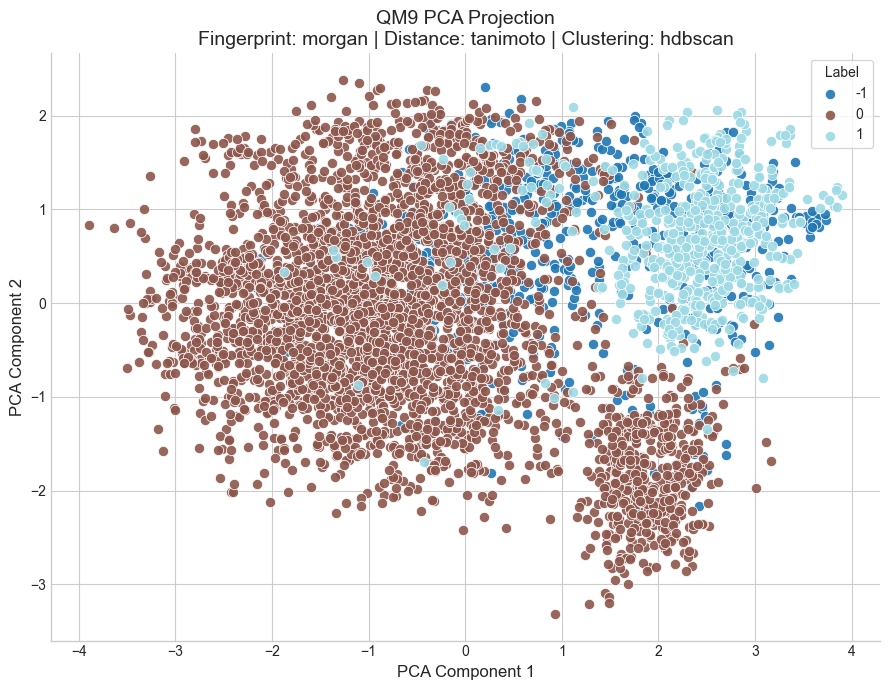

2026-04-27 19:24:18.212 | SUCCESS  | src.helper_functions:plot_distance_matrix_projection:530 - Saved PCA projection plot to figures/qm9/clustering/tanimoto/morgan/pca_hdbscan_projection.png


In [39]:
_ = plot_distance_matrix_projection(
    dist_matrix=dist_matrix,
    fingerprint="morgan",
    distance_metric="tanimoto",
    projection_method="PCA",
    dataset_name="qm9",
    labels=labels_hdbscan,
    clustering_method="hdbscan"
)

# KMeans on embedding

In [33]:
df

mol_id,formula,smiles,canonical_smiles,scaffold_smiles,generic_scaffold,root_scaffold,brics_fragments,scaffold_tree_nodes,selfies,functional_groups,structure_class,is_injected,outlier_category,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,coordinates,atomic_numbers,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,morgan_fingerprint,labels_hier,labels_km,labels_db,labels_hdbscan
str,str,str,str,str,str,str,str,str,str,str,str,i64,str,i64,i64,i64,f64,f64,i64,i64,i64,i64,i64,i64,f64,i64,f64,f64,f64,i64,i64,i64,i64,i64,i64,i64,i64,f64,i64,i64,i64,i64,i64,i64,i64,i64,i64,i64,list[list[f64]],list[i64],f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,list[i8],i64,u64,i64,i64
"""qm9_21""","""C3H8O""","""[H]OC([H])(C([H])([H])[H])C([H…","""[H]OC([H])(C([H])([H])[H])C([H…","""Acyclic""","""Acyclic""","""Acyclic""","""[4*]C([H])(C([H])([H])[H])C([H…","""""","""[H][O][C][Branch1][C][H][Branc…","""alcohol""","""Acyclic""",0,null,60,0,20,0.940086,13.015533,4,0,0,0,1,12,1.833333,3,0.0,0.0,1.0,1,1,3,0,0,3,4,24,1.199232,0,1,0,0,0,0,0,0,0,0,"[[-0.0332, 1.5478, -0.0044], [-0.0111, 0.0186, 0.0168], … [-1.8182, -0.1558, -0.6955]]","[6, 6, … 1]",1.4259,38.580002,-7.107614,2.013643,9.118535,318.372101,2.929931,-5286.280273,-5286.131348,-5286.105469,-5287.026855,19.052,-45.175072,-45.4883,-45.77108,-42.007965,8.67553,8.00568,4.75542,"[0, 1, … 0]",0,4,0,1
"""qm9_34""","""C3H6O""","""[H]C(=O)C([H])([H])C([H])([H])…","""[H]C(=O)C([H])([H])C([H])([H])…","""Acyclic""","""Acyclic""","""Acyclic""","""[H]C(=O)C([H])([H])C([H])([H])…","""""","""[H][C][=Branch1][C][=O][C][Bra…","""""","""Acyclic""",0,null,58,0,17,0.977264,12.898953,4,0,0,0,1,10,1.8,2,0.0,0.333333,0.666667,0,1,3,0,1,2,4,20,1.213143,0,0,0,0,0,0,0,0,0,0,"[[0.1688, 1.5251, -0.1575], [-0.1874, 0.0619, 0.1468], … [0.3538, 0.2066, 2.2887]]","[6, 6, … 1]",2.6741,35.830002,-6.802846,-0.557833,6.245013,333.327606,2.290518,-5253.84375,-5253.705566,-5253.679688,-5254.594727,15.954,-39.964523,-40.211521,-40.442844,-37.381725,26.145639,4.2893,4.12773,"[0, 0, … 0]",0,0,0,1
"""qm9_89""","""C3H5NO""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""O=C1CNC1""","""CC1CCC1""","""*=*1***1""","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H]N1C([H])([H])C(=O)C1([H])[H…","""[H][N][C][Branch1][C][H][Branc…","""ketone""","""Aliphatic Ring""",0,null,71,0,29,0.761845,12.992522,5,1,0,0,2,10,2.0,0,0.0,0.333333,0.666667,1,2,4,0,1,2,4,20,1.261328,0,0,0,0,0,0,0,1,0,0,"[[0.0005, 0.0067, -0.0974], [-0.0137, 1.1921, 0.0314], … [1.5674, 2.4713, -0.8115]]","[8, 6, … 1]",2.5257,39.34,-6.631414,-0.702054,5.929361,359.152008,2.167387,-6726.387695,-6726.26123,-6726.235352,-6727.135742,16.083,-40.819069,-41.077904,-41.309227,-38.114258,11.54185,4.90368,3.63309,"[0, 0, … 0]",0,10,0,1
"""qm9_92""","""C4H8O""","""[H]C1([H])O[C@@]([H])(C([H])([…","""[H]C1([H])O[C@@]([H])(C([H])([…","""C1COC1""","""C1CCC1""","""*1***1""","""[8*]C([H])([H])[H],[13*][C@]1(…","""[H]C1([H])O[C@@]([H])(C([H])([…","""[H][C][Branch1][C][H][O][C@@][…","""ether""","""Aliphatic Ring""",0,null,72,0,9,0.964858,12.880514,5,1,0,0,1,13,2.0,1,0.0,0.0,1.0,0,1,4,0,0,4,5,27,1.243901,0,0,0,0,0,0,0,0,1,0,"[[-0.3231, 1.5375, 0.0195], [0.1185, 0.089, -0.0052], … [2.9697, -0.3692, -0.4041]]","[6, 6, … 1]",1.6826,45.720001,-6.557944,2.489842,9.047786,407.690887,3.118153,-6322.054688,-6321.90918,-6321.883301,-6322.826172,18.582001,-51.086094,-51.441444,-51.749908,-47.548447,9.93129,4.56362,3.63704,"[0, 0, … 0]",0,16,0,1
"""qm9_203""","""C4H5NO""","""[H]OC1=C([H])N([H])C([H])=C1[H…","""[H]Oc1c(

In [34]:
embedding = np.array(df['morgan_fingerprint'].to_list())
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans_labels = kmeans.fit_predict(embedding)
df = df.with_columns(kmeans_labels=kmeans_labels)

In [35]:
create_chemiscope_viewer(df, embedding, kmeans_labels, 'PCA')

2026-04-27 19:21:56.964 | INFO     | src.helper_functions:create_chemiscope_viewer:1065 - Running PCA dimensionality reduction...
2026-04-27 19:21:56.965 | INFO     | src.helper_functions:create_chemiscope_viewer:1074 - Converting structures/molecules to ASE Atoms for Chemiscope...
2026-04-27 19:22:21.785 | INFO     | src.helper_functions:create_chemiscope_viewer:1142 - Assembling properties for Chemiscope...
2026-04-27 19:22:21.800 | INFO     | src.helper_functions:create_chemiscope_viewer:1237 - Generating Chemiscope widget...
2026-04-27 19:22:22.098 | SUCCESS  | src.helper_functions:create_chemiscope_viewer:1268 - Saved Chemiscope input to: qm9_PCA_clustering.json
2026-04-27 19:22:22.231 | WARNING  | src.helper_functions:create_chemiscope_viewer:1274 - If the viewer does not open automatically, run `chemiscope show qm9_PCA_clustering.json`.


<ChemiscopeWidget(meta={'name': 'QM9 - PCA Clustering'}, settings={'map': {'x': {'property': 'PCA_1'}, 'y': {'…

In [36]:
average_numeric_by_cluster(df, "kmeans_labels")

shape: (3, 75)
┌───────────────┬───────┬───────────────┬─────────────┬────────────┬─────────┬─────────┬───────────────┬───────────────┬───────────────┬───────────┬───────────────┬──────────────┬───────────────┬───────────┬──────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬───────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬────────────┬────────────┬───────────┬──────────┬──────────┬──────────────┬──────────┬───────────┬──────────┬──────────┬────────┬─────────┬─────────┬─────────┬────────┬───────────┬────────┬─────────────┬─────────────┬─────────────┬─────────────┬─────────┬──────────┬──────────┬──────────┬──────────┬──────────┬────────┬────────┬─────────────┬───────────┬───────────┬──────────────┬──────────────┬──────────────┬─────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬──────────────┬

kmeans_labels,count,token_to_atom_ratio,is_injected,mol_weight,logp,tpsa,election_affinity,ionization_energies,num_heavy_atoms,num_rings,num_aromatic_rings,num_fluorine,num_heteroatoms,num_atoms,coordination,num_rotatable_bonds,fraction_csp1,fraction_csp2,fraction_csp3,h_bond_donors,h_bond_acceptors,branching_index,num_sp_carbons,num_sp2_carbons,num_sp3_carbons,main_chain_length,raw_token_count,avg_bond_length,fr_benzene,fr_alcohol,fr_phenol,fr_amine,fr_amide,fr_carboxylic_acid,fr_ester,fr_ketone,fr_ether,fr_nitro,mu,alpha,homo,lumo,gap,r2,zpve,u0,u,h,g,cv,u0_atom,u_atom,h_atom,g_atom,A,B,C,labels_hier,labels_km,labels_db,labels_hdbscan,pct_aliphatic_ring,pct_aromatic,pct_acyclic,avg_len_selfies,unique_scaffolds,top_scaffold,top_scaffold_pct,unique_generic_scaffolds,top_generic_scaffold,top_generic_scaffold_pct,unique_outlier_categories,top_outlier_category,top_outlier_category_pct
i32,u32,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,u32,str,f64,u32,str,f64,u32,str,f64
0,750,2.020374,0.0,123.410667,-0.146667,43.058667,0.884673,12.855862,8.773333,1.136,0.117333,0.010667,2.862667,17.317333,2.010325,2.686667,0.056114,0.3297,0.614186,0.745333,2.374667,6.18,0.346667,1.829333,3.734667,6.186667,35.282667,1.259686,0.001333,0.234667,0.012,0.086667,0.276,0.002667,0.017333,0.077333,0.390667,0.0,3.305385,72.93248,-6.752371,-0.892914,5.859471,1274.595572,3.72502,-11599.275912,-11599.035174,-11599.00947,-11600.210673,31.548976,-72.858198,-73.275753,-73.689063,-67.878103,3.674413,1.228446,0.992527,0.121333,6.810667,-0.001333,0.848,64.666667,11.733333,23.6,35.282667,197,"""Acyclic""",23.6,43,"""Acyclic""",23.6,1,null,0.0
1,1894,1.956872,0.0,122.059662,0.108765,43.726505,0.798155,12.896799,8.74076,1.230201,0.418691,0.051742,2.908659,17.038015,2.025375,2.271383,0.071774,0.408637,0.51959,0.98944,2.374868,6.164731,0.445618,2.229673,3.156811,6.441922,33.724393,1.258722,0.007392,0.261352,0.069694,0.201162,0.160507,0.00264,0.074446,0.233369,0.368532,0.003168,3.057958,73.64076,-6.409095,-0.212891,6.196189,1202.638179,3.706147,-11352.64017,-11352.411315,-11352.38562,-11353.551004,30.856357,-72.388974,-72.810478,-73.218481,-67.44675,330.993737,1.391968,1.055686,0.408659,8.959345,-0.001056,0.469377,42.50264,39.915523,17.581837,33.724393,738,"""Acyclic""",17.581837,152,"""C1CCCC1""",21.752904,1,null,0.0
2,2356,2.130608,0.0,123.020374,0.110357,28.796265,0.899079,12.816269,8.812818,2.163837,0.000849,0.008913,1.956706,19.63073,2.10647,2.170204,0.067554,0.051107,0.88134,0.91511,1.619694,6.845925,0.467317,0.352716,6.036078,6.33871,42.001273,1.266417,0.0,0.447793,0.0,0.101443,0.024618,0.000424,0.013582,0.046689,0.697793,0.0,2.172714,77.093332,-6.572864,1.081923,7.654719,1153.644712,4.428321,-10893.455244,-10893.225354,-10893.199642,-10894.356313,32.282512,-79.927221,-80.437281,-80.905047,-74.305912,3.163465,1.45423,1.205549,0.014431,12.412139,-0.000424,0.857385,99.830221,0.08489,0.08489,42.001273,821,"""C1CC1""",6.748727,228,"""C1CC1""",13.752122,1,null,0.0
